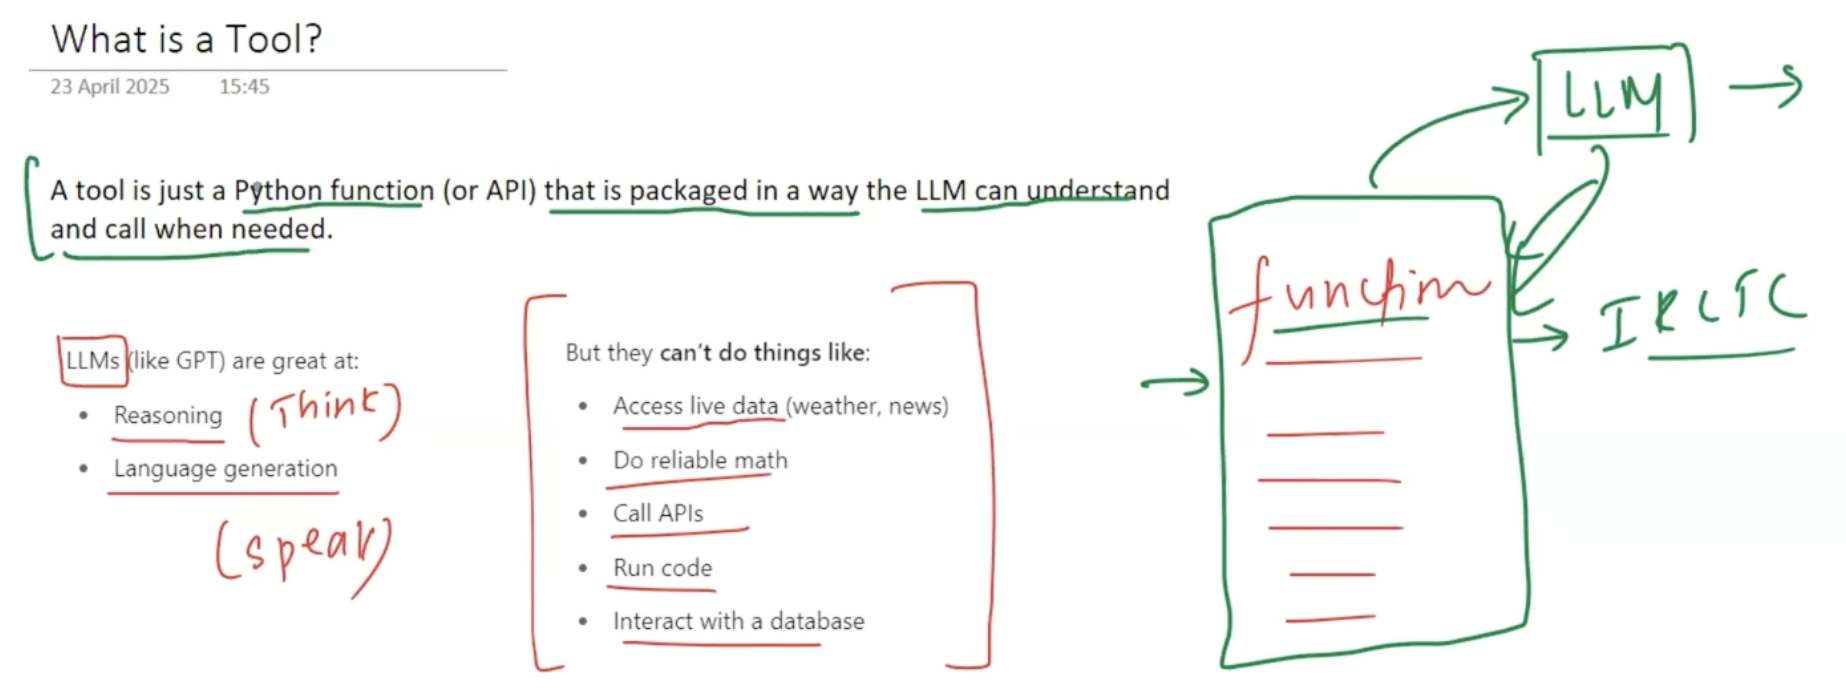

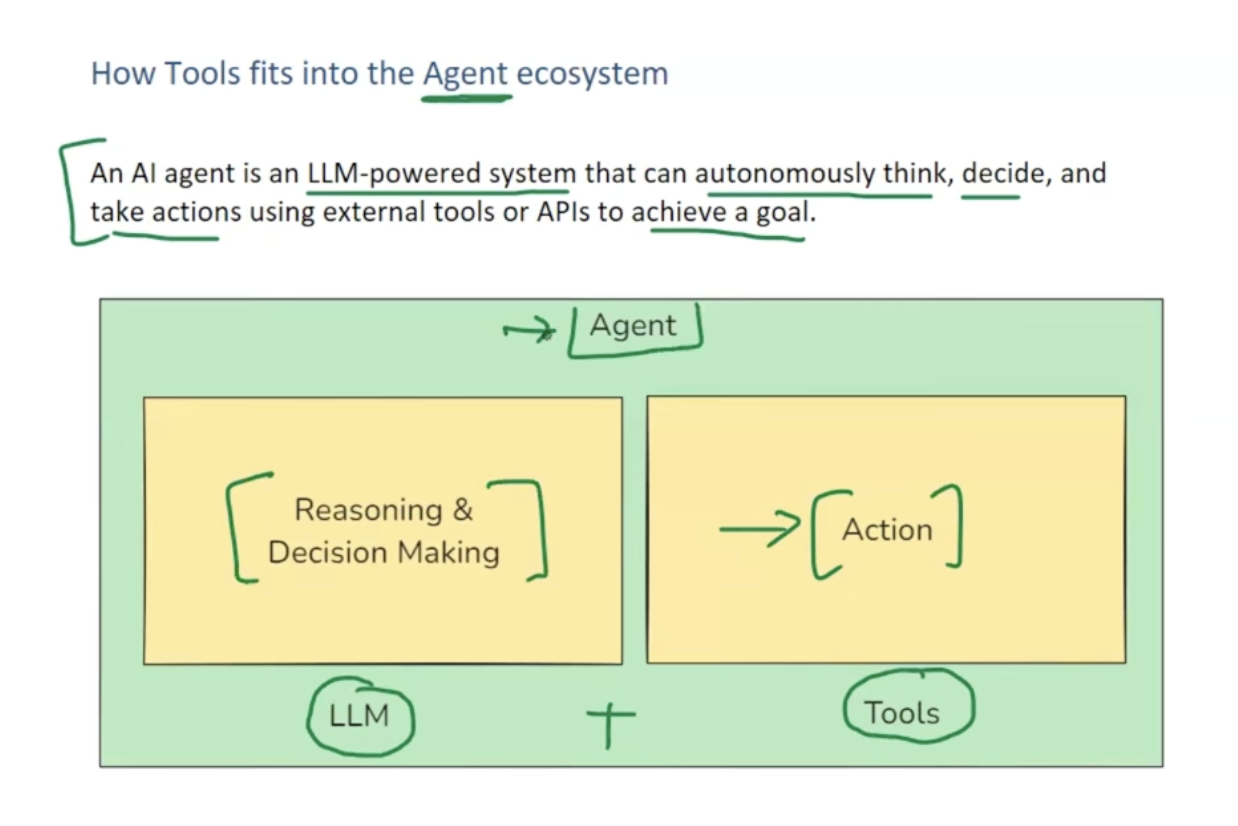

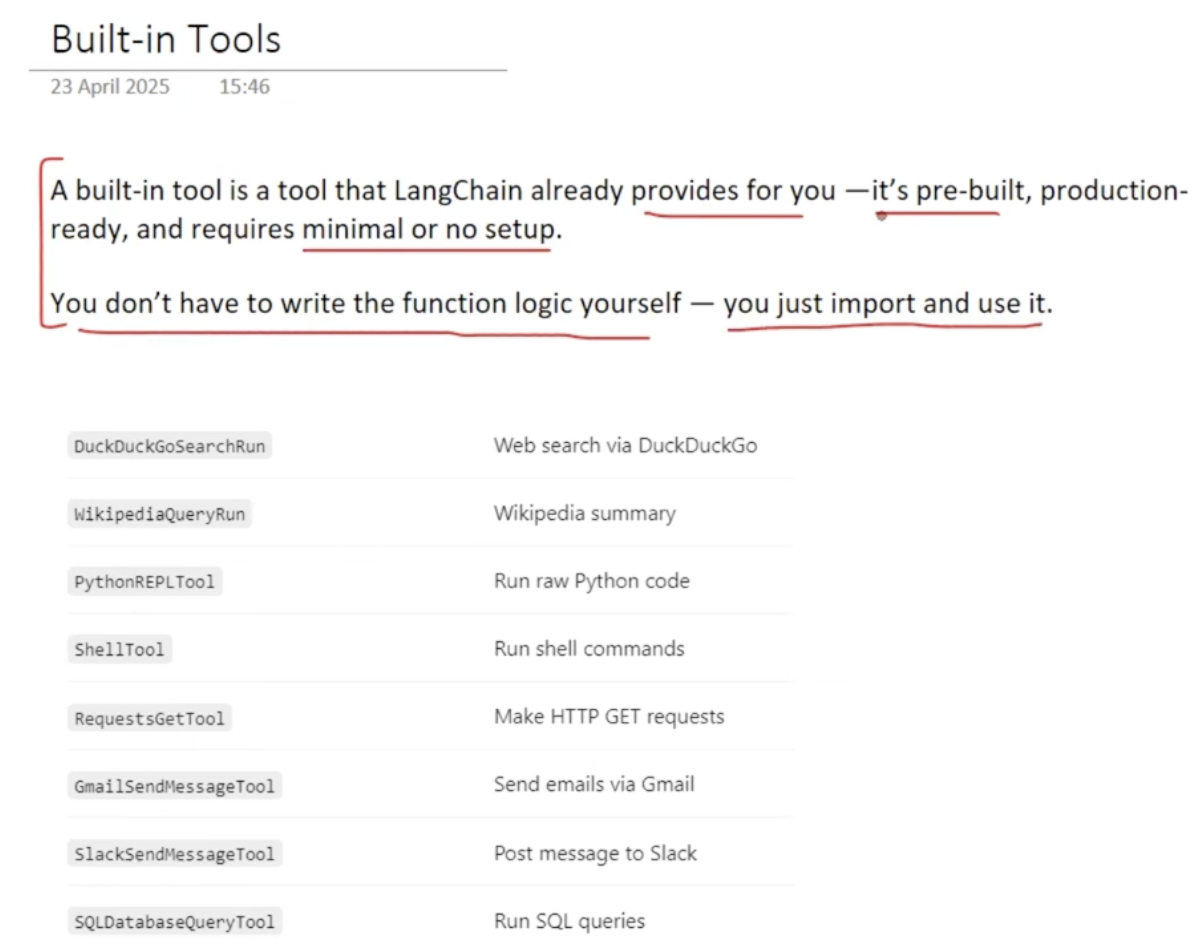

In [1]:
pip install duckduckgo-search

  Using cached click-8.1.8-py3-none-any.whl.metadata (2.3 kB)
Using cached click-8.1.8-py3-none-any.whl (98 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 7.9 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: click
    Found existing installation: click 8.1.7
    Uninstalling click-8.1.7:
      Successfully uninstalled click-8.1.7
Note: you may need to restart the kernel to use updated packages.


In [9]:
from langchain_community.tools import DuckDuckGoSearchRun

search_tool = DuckDuckGoSearchRun()

results = search_tool.invoke('top news terrorist attack in india today')

print(results)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/langchain_community/utilities/duckduckgo_search.py:64: UserWarning: backend='api' is deprecated, using backend='auto'
  ddgs_gen = ddgs.text(


The attack occurred in the Baisaran valley in Pahalgam, where a group of tourists had ventured earlier on Tuesday. The Resistance Front, believed to be a proxy of the banned Pakistan-based Lashkar-e-Taiba (LeT), has reportedly claimed responsibility for the attack, though an official confirmation from the government is still awaited. Pahalgam ... An image from video broadcast by India's ANI news agency shows security forces near to the scene of a deadly attack on tourists by suspected militants in Indian-controlled Kashmir, April 22, 2025 ... India has announced a number of punitive diplomatic measures against Pakistan on Wednesday, accusing Islamabad of supporting "cross-border terrorism" after the deadly attack on civilians in Indian ... Maharashtra deputy Chief Minister Eknath Shinde on Wednesday flew to Srinagar to expedite the process of bringing back state tourists stranded in Jammu and Kashmir, an official said here. Tensions between India and Pakistan have ramped up following a

<h1 style="color:rgb(255, 98, 0);">Built-in Tool - DuckDuckGo Search</h1>

In [10]:
print(search_tool.name)
print(search_tool.description)
print(search_tool.args)

duckduckgo_search
A wrapper around DuckDuckGo Search. Useful for when you need to answer questions about current events. Input should be a search query.
{'query': {'description': 'search query to look up', 'title': 'Query', 'type': 'string'}}


<h1 style="color:rgb(255, 98, 0);">Built-in Tool - Shell Tool</h1>

In [11]:
from langchain_community.tools import ShellTool

shell_tool = ShellTool()

results = shell_tool.invoke('ls')

print(results)

Executing command:
 ls
tools.ipynb



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/langchain_community/tools/shell/tool.py:33: UserWarning: The shell tool has no safeguards by default. Use at your own risk.
  warnings.warn(


<h1 style="color:rgb(255, 98, 0);">Ways to create Custom Tools</h1>

<h3 style="color:rgb(255, 98, 0);">Method 1 - Using @tool decorator</h3>

In [12]:
from langchain_core.tools import tool

### Step 1 - create a function

In [13]:
def multiply(a, b):
    """Multiply two numbers"""
    return a*b

### Step 2 - add type hints

In [14]:
def multiply(a: int, b:int) -> int:
    """Multiply two numbers"""
    return a*b

### Step 3 - add tool decorator

In [18]:
@tool
def multiply(a: int, b:int) -> int:
    """Multiply two numbers"""
    return a*b

result = multiply.invoke({"a":3, "b":5})
print(result)

15


In [19]:
print(multiply.name)
print(multiply.description)
print(multiply.args)

multiply
Multiply two numbers
{'a': {'title': 'A', 'type': 'integer'}, 'b': {'title': 'B', 'type': 'integer'}}


In [20]:
print(multiply.args_schema.model_json_schema())

{'description': 'Multiply two numbers', 'properties': {'a': {'title': 'A', 'type': 'integer'}, 'b': {'title': 'B', 'type': 'integer'}}, 'required': ['a', 'b'], 'title': 'multiply', 'type': 'object'}


<h3 style="color:rgb(255, 98, 0);">Method 2 - Using StructuredTool</h3>

In [21]:
from langchain.tools import StructuredTool
from pydantic import BaseModel, Field

In [22]:
class MultiplyInput(BaseModel):
    a: int = Field(required=True, description="The first number to add")
    b: int = Field(required=True, description="The second number to add")

In [23]:
def multiply_func(a: int, b: int) -> int:
    return a * b

In [24]:
multiply_tool = StructuredTool.from_function(
    func=multiply_func,
    name="multiply",
    description="Multiply two numbers",
    args_schema=MultiplyInput
)

In [25]:
result = multiply_tool.invoke({'a':3, 'b':3})

print(result)
print(multiply_tool.name)
print(multiply_tool.description)
print(multiply_tool.args)

9
multiply
Multiply two numbers
{'a': {'description': 'The first number to add', 'required': True, 'title': 'A', 'type': 'integer'}, 'b': {'description': 'The second number to add', 'required': True, 'title': 'B', 'type': 'integer'}}


<h3 style="color:rgb(255, 98, 0);">Method 3 - Using Base Tool Class</h3>

Base tool class is the abstract class for all the tools in LangChain. It defines the basic interface and some common functionality that all tools should implement.

In [26]:
from langchain.tools import BaseTool
from typing import Type

In [27]:
# arg schema using pydantic

class MultiplyInput(BaseModel):
    a: int = Field(required=True, description="The first number to add")
    b: int = Field(required=True, description="The second number to add")

In [28]:
class MultiplyTool(BaseTool):
    name: str = "multiply"
    description: str = "Multiply two numbers"

    args_schema: Type[BaseModel] = MultiplyInput

    def _run(self, a: int, b: int) -> int:
        return a * b

In [29]:
multiply_tool = MultiplyTool()

In [30]:
result = multiply_tool.invoke({'a':3, 'b':3})

print(result)
print(multiply_tool.name)
print(multiply_tool.description)

print(multiply_tool.args)

9
multiply
Multiply two numbers
{'a': {'description': 'The first number to add', 'required': True, 'title': 'A', 'type': 'integer'}, 'b': {'description': 'The second number to add', 'required': True, 'title': 'B', 'type': 'integer'}}


<h1 style="color:rgb(255, 98, 0);">Toolkits</h1>

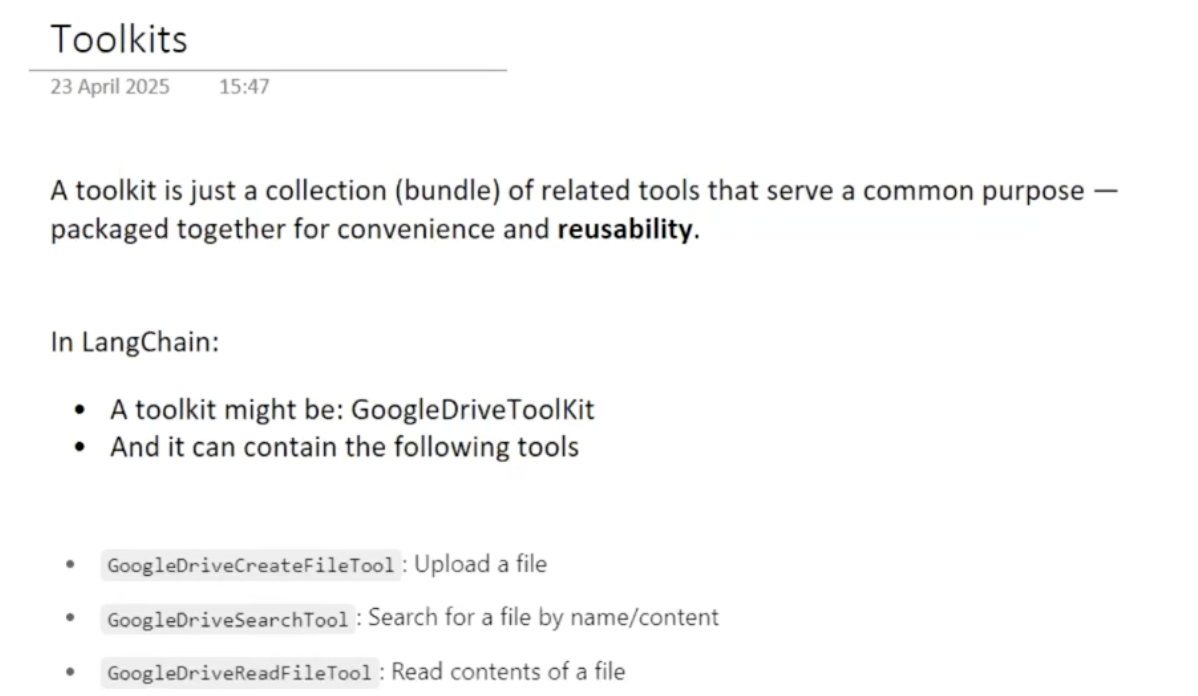

In [31]:
from langchain_core.tools import tool

# Custom tools
@tool
def add(a: int, b: int) -> int:
    """Add two numbers"""
    return a + b

@tool
def multiply(a: int, b: int) -> int:
    """Multiply two numbers"""
    return a * b


In [32]:
class MathToolkit:
    def get_tools(self):
        return [add, multiply]


In [33]:
toolkit = MathToolkit()
tools = toolkit.get_tools()

for tool in tools:
    print(tool.name, "=>", tool.description)


add => Add two numbers
multiply => Multiply two numbers
